# SAMOS Core 3 Assignment 
## St Helena Bay Chlorophyll and Bathymetry Analysis
This notebook investigates the spatial and seasonal variability of chlorophyll-a concentrations in the St Helena Bay region using ESA-CCI satellite data and GMRT bathymetry data.



In [1]:
# Import modules
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# Load chlorophyll dataset
chl = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# Load bathymetry dataset
bathy = xr.open_dataset("GMRTv4_4_1_20260513topo2.grd")

# Display metadata information for both datasets
print(chl)
print(bathy)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
  

In [3]:
# Define study region
lon_min = 17
lon_max = 18.5
lat_min = -33.5
lat_max = -31.5

# Subset chlorophyll dataset
chl_region = chl.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min)
)

# Check subset
print(chl_region)

<xarray.Dataset> Size: 84kB
Dimensions:  (time: 12, lat: 48, lon: 36)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 384B -31.52 -31.56 -31.6 ... -33.4 -33.44 -33.48
  * lon      (lon) float64 288B 17.02 17.06 17.1 17.15 ... 18.4 18.44 18.48
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 83kB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id

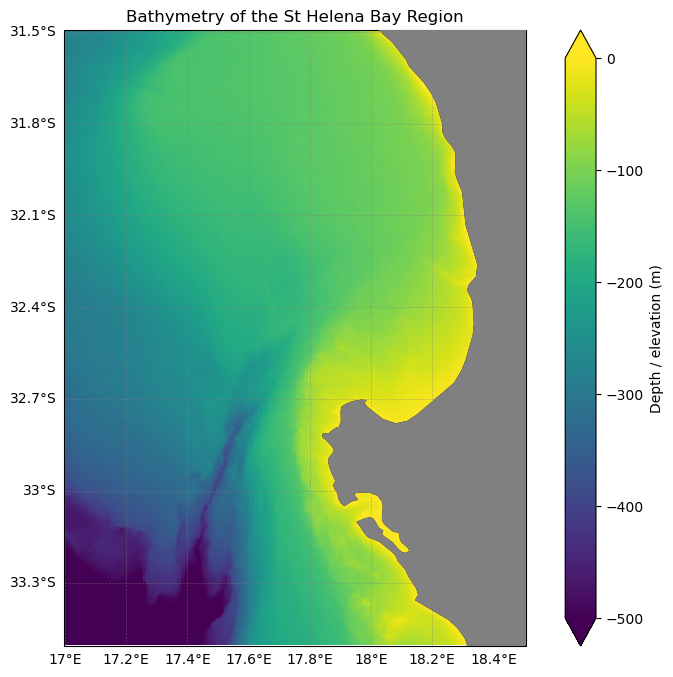

In [4]:

# Plot Bathymetry Figure
fig = plt.figure(figsize=(10, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

bathy["altitude"].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=-500,
    vmax=0,
    cbar_kwargs={"label": "Depth / elevation (m)"}
)

ax.coastlines(resolution="10m")

# Land colour
ax.add_feature(cfeature.LAND, color="grey", zorder=3)

# Gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

ax.set_title("Bathymetry of the St Helena Bay Region")

# Save the figure
fig.savefig("bathymetry_map.png", dpi=300, bbox_inches="tight")

# Show figure
plt.show()

In [5]:
# Remove zero and negative chlorophyll values
chl_clean = chl_region["chlor_a"].where(chl_region["chlor_a"] > 0)

In [6]:
# Calculate annual mean chlorophyll
chl_annual = chl_clean.mean(dim="time", skipna=True)

# Display annual Chlorophyll mean
print(chl_annual)

<xarray.DataArray 'chlor_a' (lat: 48, lon: 36)> Size: 7kB
array([[1.3066239 , 1.3948013 , 1.5718495 , ...,        nan,        nan,
               nan],
       [1.4144803 , 1.4144803 , 1.5499796 , ...,        nan,        nan,
               nan],
       [1.3987126 , 1.5392566 , 1.7475349 , ...,        nan,        nan,
               nan],
       ...,
       [0.49871817, 0.52768594, 0.55815536, ...,        nan,        nan,
               nan],
       [0.4668003 , 0.5023976 , 0.5351952 , ...,        nan,        nan,
               nan],
       [0.47902834, 0.5067981 , 0.5067981 , ...,        nan,        nan,
               nan]], shape=(48, 36), dtype=float32)
Coordinates:
  * lat      (lat) float64 384B -31.52 -31.56 -31.6 ... -33.4 -33.44 -33.48
  * lon      (lon) float64 288B 17.02 17.06 17.1 17.15 ... 18.4 18.44 18.48
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
 

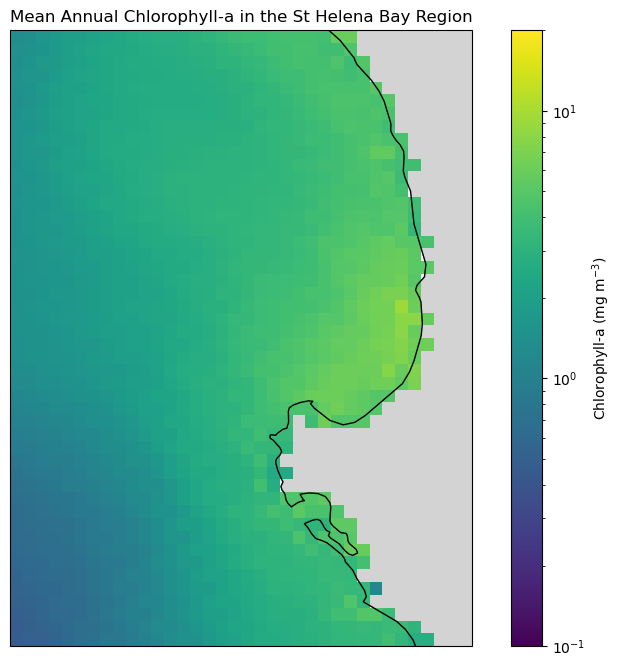

In [7]:
# Import matplotlib.colors
import matplotlib.colors as colors

# Plot mean annual chlorophyll
fig = plt.figure(figsize=(10, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

chl_annual.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    norm=colors.LogNorm(vmin=0.1, vmax=20),
    cbar_kwargs={"label": "Chlorophyll-a (mg m$^{-3}$)"}
)

ax.coastlines(resolution="10m")

ax.add_feature(cfeature.LAND, color="lightgrey")

ax.set_title("Mean Annual Chlorophyll-a in the St Helena Bay Region")

# Save the figure
fig.savefig("chl_annual_map.png", dpi=300, bbox_inches="tight")

# Show figure
plt.show()

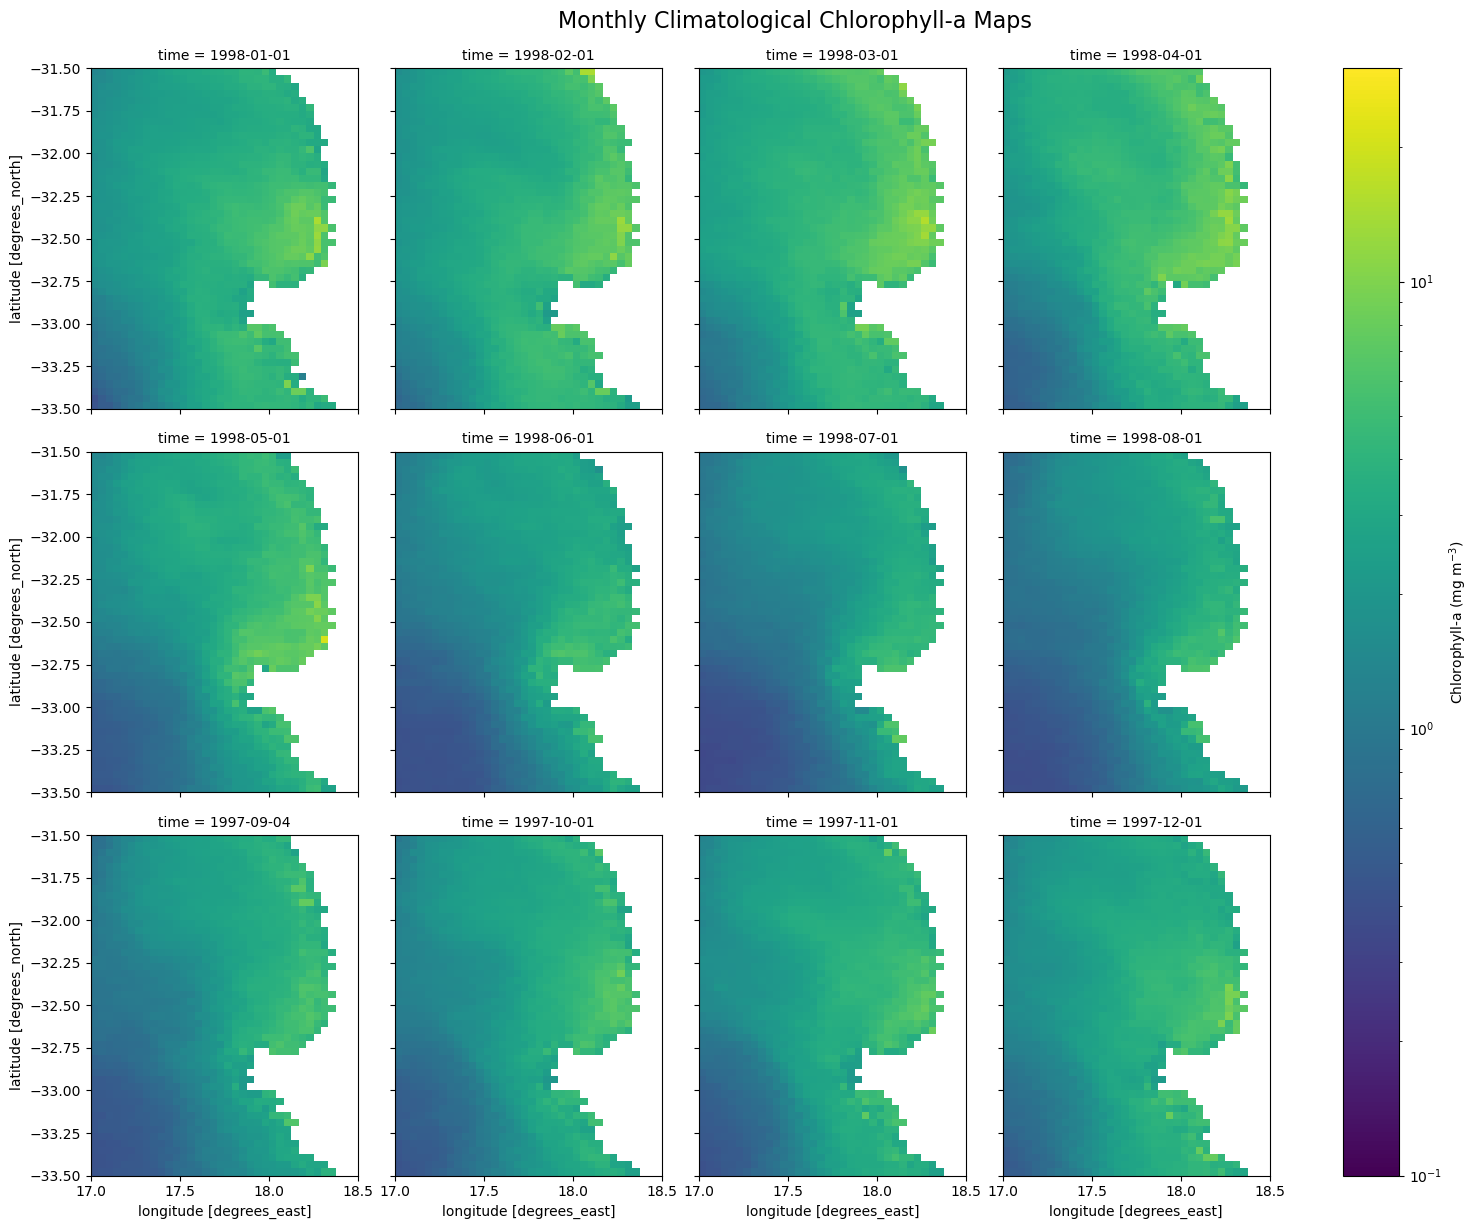

In [8]:
# Plot monthly chlorophyll-a maps
g = chl_clean.plot(
    col="time",
    col_wrap=4,
    figsize=(16, 12),
    cmap="viridis",
    norm=colors.LogNorm(vmin=0.1, vmax=30),
    cbar_kwargs={"label": "Chlorophyll-a (mg m$^{-3}$)"}
)

g.fig.suptitle(
    "Monthly Climatological Chlorophyll-a Maps",
    fontsize=16,
    y=1.02
)

# Save the faceted plot
g.fig.savefig(
    "monthly_climatological_chlorophyll_maps.png",
    dpi=300,
    bbox_inches="tight"
)
# Show figure
plt.show()

In [9]:
# Calculate regional mean
regional_mean = chl_clean.mean(
    dim=["lat", "lon"],
    skipna=True
)

# Display regional mean
print(regional_mean)

<xarray.DataArray 'chlor_a' (time: 12)> Size: 48B
array([3.2580361, 3.5576708, 4.0516243, 3.8419378, 2.936165 , 2.007594 ,
       1.7454422, 1.7844055, 2.128442 , 2.4462683, 2.672148 , 2.7981875],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3


In [10]:
# Define selected point coordinates
point_lon = 18.0
point_lat = -32.0

# Select nearest grid point
point_series = chl_clean.sel(
    lon=point_lon,
    lat=point_lat,
    method="nearest"
)

# Display selected points
print(point_series)

<xarray.DataArray 'chlor_a' (time: 12)> Size: 48B
array([4.0952153, 4.1249137, 5.5550513, 5.0433035, 4.3669267, 3.044961 ,
       2.7413185, 2.7563186, 3.2607305, 3.480955 , 3.6545982, 3.5222063],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
    lon      float64 8B 18.02
    lat      float64 8B -32.02
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3


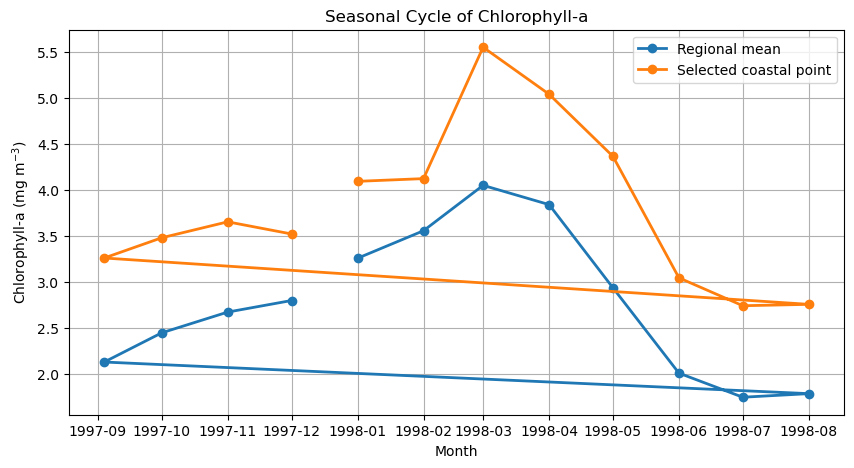

In [11]:
# Plot seasonal cycle of chlorophyll-a
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    regional_mean["time"],
    regional_mean,
    marker="o",
    linewidth=2,
    label="Regional mean"
)

ax.plot(
    point_series["time"],
    point_series,
    marker="o",
    linewidth=2,
    label="Selected coastal point"
)

ax.set_xlabel("Month")
ax.set_ylabel("Chlorophyll-a (mg m$^{-3}$)")
ax.set_title("Seasonal Cycle of Chlorophyll-a")
ax.legend()
ax.grid(True)

# Save Figure
fig.savefig("chlorophyll_seasonal_cycle.png", dpi=300, bbox_inches="tight")

# Show figure
plt.show()